# Heart Failure Prediction Models
Group 7

### Dataset used: 
[Heart Failure Prediction](https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data/data)

In [20]:
import warnings
warnings.filterwarnings("ignore")

## 1. Load and preprocess data.

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv('HFCR_dataset.csv')
print("First few rows to inspect:")
df.head()

First few rows to inspect:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Describe data to see if scaling in necessary and check data types to see if conversion is necessary.

In [22]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [23]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Split dataset into data and target.

In [24]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (299, 12)
y shape: (299,)


Check data incase there are missing values.

In [25]:
print(X.isnull().sum())
print('-----------------------------')
print(y.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
dtype: int64
-----------------------------
0


Split training data, we will use a test set of 20%. Then split the data (split 20% validation set size) again for future model validation.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
split_X_train, X_val, split_y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state = 0, stratify=y_train)

Scaling was necessary due to big differences in ranges.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Create pipeline to combine the scaler with the selected machine learning models. Use LogisticRegression() as a placeholder for classifier.

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", scaler),
    ("classifier", LogisticRegression(max_iter=1000, random_state=0))
])

## 2. Begin Model Selection Testing

Build Parameter Grid and implement the grid search.

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
    'classifier': [LogisticRegression(max_iter=1000, random_state=0)],
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__fit_intercept': [True, False]
    },
    {
    'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
    },
    {
    'classifier': [RandomForestClassifier(random_state=0)],
    'classifier__n_estimators': [300, 400, 500],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [10, 20, 50],
    'classifier__min_samples_leaf': [5, 10, 20],
    'classifier__max_features': ['sqrt', 'log2'],
    }
]

grid = GridSearchCV(pipe, param_grid, cv=5, return_train_score=True, n_jobs=-1)
grid.fit(split_X_train, split_y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=0))]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000,
                                                            random_state=0)],
                          'classifier__C': [0.1, 1, 10, 100],
                          'classifier__fit_intercept': [True, False],
                          'classifier__penalty': ['l1', 'l2']},
                         {'classifier': [KNe...
                          'classifier__n_neighbors': [3, 5, 7, 9],
                          'classifier__weights': ['uniform', 'distance']},
                         {'classifier': [RandomForestClassifier(random_state=0)],
                          'classifier__max_depth': [5, 10, None],
                          'classifier__max_features': ['sqrt', 'log2'],
                          'classifier__min_samples_leaf': [5, 10, 20],
                          'classifier__min_samples_split': [10, 20, 50],
                          'classifier__n_estimators': [300, 400, 500]}],
             return_train_score=True)

Print grid search results to find best model

In [30]:
print("Best params:\n{}\n".format(grid.best_params_))
print("Best cross-validation train score: {:.2f}".format(grid.cv_results_['mean_train_score'][grid.best_index_]))
print("Best cross-validation test score: {:.2f}".format(grid.best_score_))
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Best params:
{'classifier': RandomForestClassifier(random_state=0), 'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}

Best cross-validation train score: 0.91
Best cross-validation test score: 0.86
Test-set score: 0.88


Create heatmap confusion matrix to visually represent results, and include classification report to track values on the model if modification is necessary.

## 3. Results Visualization & Tuning

Text(113.9222222222222, 0.5, 'true value')

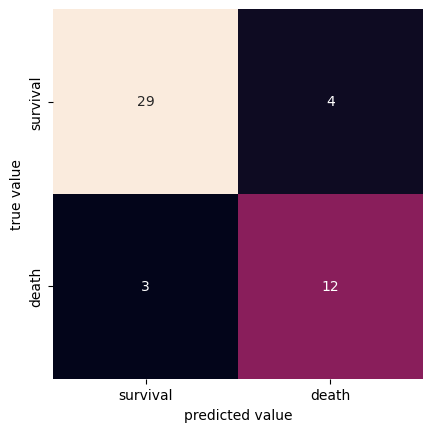

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

best_model = grid.best_estimator_
y_pred = best_model.predict(X_val)

mat = confusion_matrix(y_val, y_pred)

sns.heatmap(mat, xticklabels=['survival', 'death'],  yticklabels=['survival', 'death'], square=True, annot=True, cbar=False, fmt='d')
plt.xlabel('predicted value')
plt.ylabel('true value')

In [32]:
print(classification_report(y_val, y_pred, target_names=['Survival', 'Death']))

              precision    recall  f1-score   support

    Survival       0.91      0.88      0.89        33
       Death       0.75      0.80      0.77        15

    accuracy                           0.85        48
   macro avg       0.83      0.84      0.83        48
weighted avg       0.86      0.85      0.86        48



In the context of our dataset, we would rather predict a death and have the patient survive as opposed to predicting survival and risking a patient dying as a result of our decision. So we are going to decrease the threshold to move the boundary towards the negative class, growing the positive class region increasing recall but decreasing our precision.

Text(113.9222222222222, 0.5, 'true value')

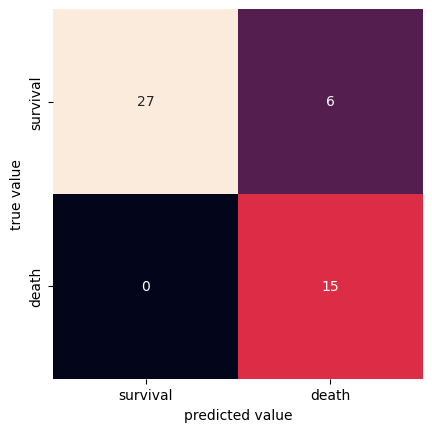

In [33]:
probabilities = best_model.predict_proba(X_val)[:, 1]

new_pred = (probabilities >= 0.30).astype(int)

mat = confusion_matrix(y_val, new_pred)
sns.heatmap(mat, xticklabels=['survival', 'death'],  yticklabels=['survival', 'death'], square=True, annot=True, cbar=False, fmt='d')
plt.xlabel('predicted value')
plt.ylabel('true value')

In [34]:
print(classification_report(y_val, new_pred, target_names=['Survival', 'Death']))

              precision    recall  f1-score   support

    Survival       1.00      0.82      0.90        33
       Death       0.71      1.00      0.83        15

    accuracy                           0.88        48
   macro avg       0.86      0.91      0.87        48
weighted avg       0.91      0.88      0.88        48



Trial and error gave us our best threshold to be about 0.30 which minimizes the number of false postives while still decreasing the number of false negatives which we primarily wanted to reduce.

## Results
### Best Model
Based on our results the best classifier is the `RandomForestClassifer` with the following parameters:
- `max_depth = 5`
- `max_features = sqrt`
- `min_samples_leaf = 5`
- `min_samples_split = 10`
- `n_estimators = 300`

This returns a cross-validation train score of `0.91`, test score of `0.86` and a test-set score of `0.88`

### Final Notes

When splitting data and instantiating models we used random_state=0 just so runs would be consistent and results wouldn't change.
Additionally when comparing results we did go back and modify parameters in the grid search specifically for `RandomForestClassifier` to further improve it as it was already performing the best but tended to overfit.

#### Sources
Assignments 2, 3, & 4 from ENSF 444 (Winter 2026) used as reference and for structure guidance.
AI used for parameter tuning recommendations, no code itself was sourced from AI. [Perplexity](https://www.perplexity.ai/)